In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from neuron import h
from plastic_neuron import PlasticNeuron
from abstract_neuron import AbstractNeuron
from neuron_utils import NeuronUtils
from neuron_plots import NeuronPlots

# LTP → Unsynchronized Poisson inputs in theta rhythm (without EF)

In [2]:
synapse_info = pd.read_csv("final_no_ef.csv", index_col = 0)
synapse_info.Delay = 0
synapse_info

,Dendrite,Location,Distance,Delay,Conductance,InitialWeight
0,14,0.139538,116.315870,0,0.0001,0.560001
1,6,0.676699,119.467511,0,0.0001,0.122262
2,27,0.031783,214.478018,0,0.0001,0.086850
3,5,0.218638,125.874136,0,0.0001,0.129521
4,26,0.220441,237.214368,0,0.0001,0.083688
5,37,0.278191,286.953628,0,0.0001,0.085029
6,21,0.277871,179.285582,0,0.0001,0.092382
7,13,0.957213,199.340123,0,0.0001,0.660946
8,21,0.102210,153.333687,0,0.0001,0.094956
9,24,0.096716,191.699553,0,0.0001,0.088838


In [3]:
def generate_poisson(
        frequency = 5,
        burst_duration = 50,
        duration = 1000,
        rate_in_burst = 100,
        rate_outside_burst = 1
):
    burst_times = np.arange(0, duration, 1000 / frequency)
    spike_times = []

    for t_burst in burst_times:
        # Generate Poisson spikes inside the burst window
        n_spikes = np.random.poisson(rate_in_burst * (burst_duration / 1000))
        spikes = t_burst + np.random.uniform(0, burst_duration, size = n_spikes)
        spike_times.extend(spikes)

        # Generate sparse spikes outside bursts
        outside_duration = (1000 / frequency) - burst_duration
        if outside_duration > 0:
            n_out = np.random.poisson(rate_outside_burst * (outside_duration / 1000))
            spikes_out = t_burst + burst_duration + np.random.uniform(0, outside_duration, size = n_out)
            spike_times.extend(spikes_out)

    spike_times = np.sort(np.array(spike_times))
    return spike_times

In [6]:
# Parameters
rate = 5  # Hz
duration = 5 * 1000  # ms # TODO: change to a minute

In [7]:
# Generate a list of random seeds to use when generating stimuli
np.random.seed(132)
seeds = np.random.choice(range(10000), 10, replace=False)

seed_counter = -1

# Define the stimulus
def poisson_theta():
    global seed_counter
    seed_counter += 1
    
    np.random.seed(seeds[seed_counter])
    
    # Generate spike times
    spike_times = generate_poisson(frequency = rate, duration = duration)
    spike_vec = h.Vector(spike_times)
    
    stimulus = h.VecStim()
    stimulus.play(spike_vec)
    
    return stimulus

In [8]:
neuron = PlasticNeuron(
    synapse_info = synapse_info,
    generate_stimulus = poisson_theta
)

Creating cell
	1 
	1 
	0 
23 
After any change to cell geometry or nseg, be sure to invoke setpointers()
Reading synapse information
Inserting 10 synapses


In [9]:
NeuronUtils.set_stimulus(
    duration = 0
)

In [10]:
neuron.run(duration)

Neuron initialized
Elapsed time: 117.13 seconds


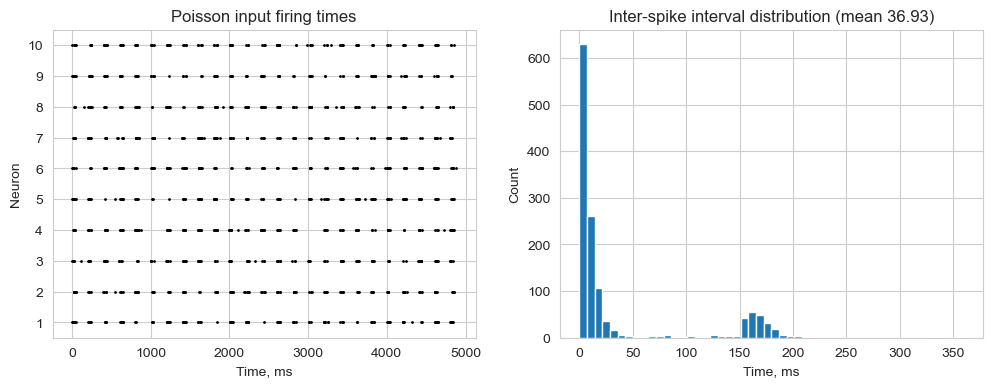

In [11]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 4))

for i, synapse in enumerate(neuron.synapses):
    time = synapse.stimuli
    axs[0].scatter(time, np.repeat(i + 1, repeats = len(time)), color = "black", s = 1)

axs[0].set_ylim(0.5, 10.5)
axs[0].set_ylabel("Neuron")
axs[0].set_yticks(np.arange(1, 11, 1))
axs[0].set_xlabel("Time, ms")
axs[0].set_title("Poisson input firing times")

freqs = []
for synapse in neuron.synapses:
    freqs.append(np.diff(synapse.stimuli)[1:])
freqs = np.concatenate(freqs)

axs[1].hist(freqs, bins = 50)
axs[1].set_xlabel("Time, ms")
axs[1].set_ylabel("Count")
axs[1].set_title(f"Inter-spike interval distribution (mean {round(np.mean(freqs), 2)})")

plt.show()

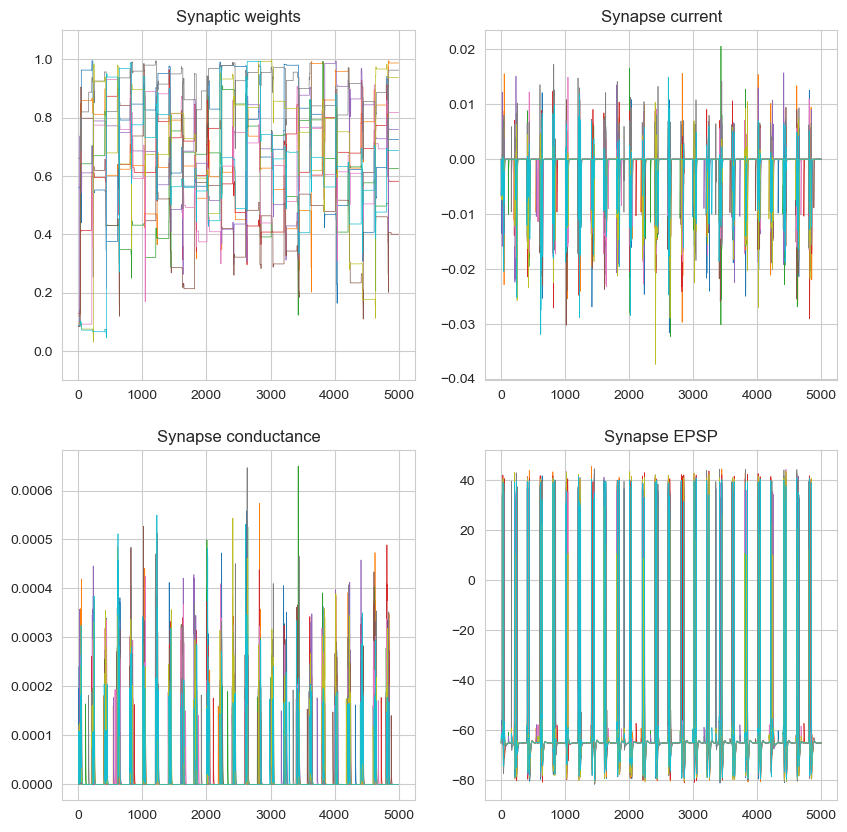

In [12]:
NeuronPlots.plot_all_synapses(neuron)

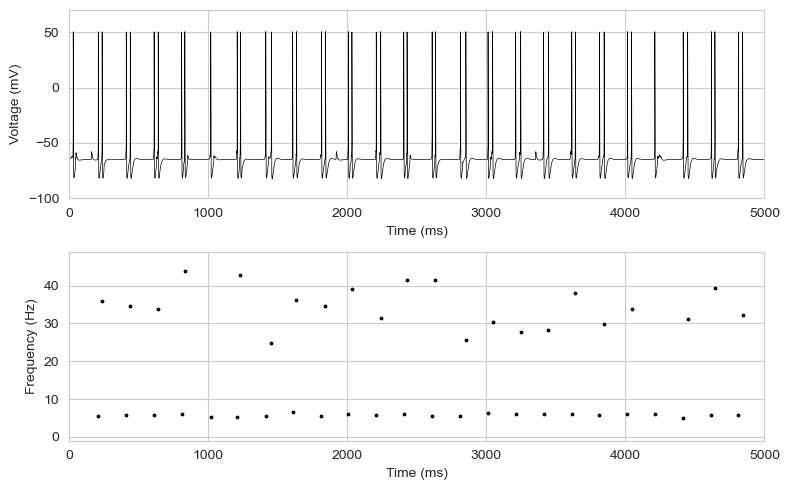

In [13]:
NeuronPlots.plot_spike_frequency(neuron)